# TinyML Fall Detection — One-Class Multi-Prototype Model

Questo notebook addestra un modello **one-class FALL** coerente con il generatore Contiki-NG del progetto.

Pipeline:

1. utilizzo degli 8 template reali SisFall da 20 campioni e 9 segnali;
2. generazione di varianti FALL con lo stesso rumore del nodo;
3. estrazione di 21 feature temporali;
4. apprendimento di 8 prototipi, uno per famiglia di caduta;
5. calibrazione della soglia su un validation set FALL indipendente;
6. valutazione dei falsi positivi su finestre NORMAL sintetiche;
7. esportazione dei parametri in un header C.

Il training usa soltanto esempi FALL. Le finestre NORMAL vengono usate esclusivamente per la valutazione e la scelta della soglia operativa.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Tuple
import json

import numpy as np
import matplotlib.pyplot as plt

RANDOM_SEED = 42

NUM_TEMPLATES = 8
WINDOW_SIZE = 20
NUM_CHANNELS = 9
NUM_FEATURES = 21

TRAIN_VARIANTS_PER_TEMPLATE = 2000
VALIDATION_VARIANTS_PER_TEMPLATE = 500
NUM_NORMAL_TEST_WINDOWS = 10000

ACC_NOISE_MG = 30
GYRO_NOISE_DPS = 5

FEATURE_NAMES = [
    "adxl_mean", "adxl_variance", "adxl_min", "adxl_max",
    "adxl_range", "adxl_mean_abs_diff", "adxl_max_abs_diff",
    "gyro_mean", "gyro_variance", "gyro_min", "gyro_max",
    "gyro_range", "gyro_mean_abs_diff", "gyro_max_abs_diff",
    "mma_mean", "mma_variance", "mma_min", "mma_max",
    "mma_range", "mma_mean_abs_diff", "mma_max_abs_diff",
]

print("Configurazione caricata.")


Configurazione caricata.


## 1. Dati incorporati dal generatore C

Unità:

- ADXL345 e MMA8451Q: milli-g;
- ITG3200: gradi al secondo.

Ordine delle colonne:

`adxl_x, adxl_y, adxl_z, itg_x, itg_y, itg_z, mma_x, mma_y, mma_z`.

In [2]:
NORMAL_QUANTILES = np.array(
[[-996, -215, -55, 12, 90, 223, 1008], [-2621, -1215, -1004, -949, -758, -168, 375], [-1219, -574, -340, -141, 74, 316, 934], [-120, -26, -6, -1, 6, 27, 117], [-93, -24, -3, 3, 8, 29, 96], [-79, -22, -4, 0, 3, 21, 77], [-986, -214, -60, 4, 69, 198, 978], [-2537, -1187, -982, -927, -747, -162, 353], [-1193, -547, -293, -83, 126, 373, 991]],
    dtype=np.int32,
)

FALL_TEMPLATES = np.array(
[[[-66, -699, -629, -27, 5, 23, -55, -714, -633], [-176, -605, -730, -36, 20, 42, -163, -598, -728], [-195, -465, -789, -21, 20, 36, -186, -487, -777], [-195, -426, -805, -6, 9, 22, -172, -424, -821], [-184, -422, -816, 7, 27, 31, -172, -426, -813], [-125, -375, -691, 5, 62, 20, -113, -388, -684], [-86, -449, -906, -52, 39, 29, -81, -426, -912], [242, -270, -766, -102, 152, -49, 247, -264, -759], [1387, 422, 281, -10, 144, 58, 1379, 421, 299], [727, -199, 488, 58, 34, 5, 719, -201, 511], [984, -180, 152, 7, -60, -16, 978, -194, 194], [1043, 148, -59, -21, -60, -6, 1031, 138, -24], [973, 8, -238, -15, -24, 11, 968, 16, -228], [945, -98, -312, -1, -5, -1, 938, -92, -303], [953, 16, -262, 5, 6, -5, 959, 23, -247], [973, 0, -242, 3, 1, 1, 959, -1, -240], [961, -8, -250, 3, -4, -1, 951, -4, -228], [957, 0, -277, 3, -1, -1, 950, -2, -268], [965, -8, -297, 4, 2, -1, 961, 3, -260], [957, 0, -266, 3, 1, 0, 959, 8, -245]], [[102, -855, 367, 5, 2, 0, 20, -814, 529], [90, -828, 395, 9, 3, -1, 9, -795, 560], [90, -801, 453, 12, 7, -4, 9, -772, 598], [117, -797, 473, 13, 11, -1, 31, -779, 631], [94, -711, 527, 26, 18, 5, 18, -681, 689], [39, -609, 598, 39, 24, 3, -37, -592, 758], [-35, -438, 590, 68, 43, 20, -147, -417, 755], [-125, -82, 309, 98, 98, 49, -205, -77, 482], [-2758, 715, 820, 56, -86, 19, -2737, 735, 1002], [-859, 180, -39, -35, -8, -30, -908, 192, 121], [-191, -625, 1043, -40, 28, -47, -280, -590, 1201], [-703, -39, 516, -1, -4, 7, -766, -36, 688], [-699, -4, 500, 4, -8, -2, -762, 10, 681], [-648, 51, 555, 7, 0, 2, -706, 55, 710], [-656, 8, 531, 4, -3, 1, -732, 29, 714], [-621, 62, 559, -1, 2, -1, -688, 64, 722], [-629, 43, 543, -2, -1, 1, -689, 53, 728], [-625, 35, 562, -4, 2, -1, -688, 41, 723], [-605, 43, 551, -2, 2, 0, -683, 55, 718], [-633, 31, 562, -3, 0, -1, -686, 46, 736]], [[20, -984, -168, 3, 0, 1, 57, -950, -209], [39, -977, -191, 7, -4, -3, 55, -943, -192], [43, -941, -164, 0, -3, -5, 67, -911, -203], [8, -883, -176, -13, -13, 11, 35, -845, -220], [70, -852, -172, -4, 3, 23, 99, -820, -205], [-121, -898, -145, 10, 10, 34, -95, -858, -186], [-117, -941, -234, 16, 14, 47, -104, -901, -265], [-363, -828, -195, 4, -29, 49, -335, -812, -223], [-1918, -1016, 664, 55, -105, 156, -1824, -1010, 626], [-875, 35, 871, 91, -35, 220, -833, 36, 852], [-562, 543, -4, 98, 32, 48, -557, 491, -19], [-605, 527, 145, 29, 18, -118, -607, 501, 122], [-1055, -160, -121, -4, 31, -6, -1030, -173, -139], [-1000, -74, -35, -4, -22, 0, -994, -74, -42], [-949, 74, 273, 7, -3, 6, -923, 58, 233], [-1023, 39, 82, -1, 9, -3, -1010, 25, 82], [-977, -20, 184, -5, -2, -1, -952, -26, 172], [-992, 0, 172, 2, 5, -1, -976, -14, 148], [-1027, 12, 137, 1, 1, -2, -1005, -7, 139], [-988, -12, 203, -3, 5, -2, -966, -21, 178]], [[8, -844, -324, -22, -12, 5, -11, -876, -308], [-39, -836, -414, -38, -6, 7, -59, -860, -412], [-55, -746, -504, -32, 0, 0, -56, -766, -509], [-39, -645, -602, -30, -4, 0, -54, -656, -621], [-66, -672, -762, -13, -3, 3, -75, -696, -772], [-43, -688, -805, -3, 4, 34, -50, -698, -826], [129, -402, -582, 23, -66, 9, 113, -439, -580], [-137, -539, -660, 9, -77, 4, -136, -547, -656], [-2137, -1328, 102, 67, -238, 86, -2105, -1320, 111], [-766, 246, 1012, 77, -45, 81, -802, 174, 1036], [-699, 191, 188, 4, -86, 14, -752, 140, 197], [-520, -219, 1047, -30, -37, -34, -602, -229, 1083], [-297, -355, 777, 25, 30, -41, -344, -372, 810], [-590, -203, 777, 54, 4, -28, -642, -224, 828], [-555, -191, 750, -6, 23, 2, -610, -203, 771], [-586, -117, 727, 5, 3, 4, -637, -145, 755], [-570, -242, 809, -5, -15, -5, -637, -263, 823], [-469, -266, 797, 5, 8, -3, -519, -296, 823], [-621, -188, 730, 5, 8, 2, -655, -218, 745], [-559, -219, 746, 3, -10, 1, -630, -252, 759]], [[422, -1469, -1023, -6, 23, 0, 432, -1478, -1047], [102, -844, -441, -6, -23, 11, 112, -857, -444], [121, -496, -270, 20, 7, 25, 118, -517, -273], [-125, -1223, -1082, -33, -44, -9, -99, -1258, -1097], [31, -883, -578, -24, 7, -15, 46, -896, -591], [-4, -531, -426, -25, -42, -27, 23, -545, -447], [-117, -797, -527, -74, -31, -22, -97, -798, -539], [-297, -375, -113, 33, -190, -19, -314, -387, -104], [-3820, -344, -1707, -111, -316, 195, -3748, -396, -1716], [-367, 426, 199, 88, 101, 57, -377, 405, 171], [-867, 582, -273, -7, 12, 3, -867, 584, -275], [-875, 492, -465, 45, 34, 3, -875, 484, -482], [-902, 184, -281, 35, 4, 22, -902, 170, -256], [-684, 500, -574, -1, 9, -3, -682, 504, -591], [-770, 480, -551, 5, -18, -7, -785, 489, -597], [-723, 445, -504, 4, 1, -4, -734, 429, -515], [-770, 445, -527, 2, -2, -1, -773, 441, -544], [-746, 484, -559, -1, 9, 5, -750, 474, -589], [-723, 496, -570, 1, 11, 6, -716, 490, -590], [-711, 512, -605, 3, 16, 5, -702, 507, -633]], [[59, -957, 62, 23, -15, 10, 87, -912, 21], [199, -1215, -289, 10, 50, -41, 207, -1161, -335], [250, -734, -113, 15, 40, 8, 260, -711, -140], [4, -895, -78, -10, 85, 8, 32, -852, -111], [-117, -1316, 78, -26, 108, 32, -103, -1242, 50], [-43, -691, -215, -28, 138, 8, -17, -659, -255], [4, -375, -238, -48, 152, 44, 17, -342, -266], [285, -789, -199, -52, 65, -10, 297, -749, -229], [1703, -2922, 250, 180, 128, -137, 1746, -2741, 194], [285, 402, 488, 12, -1, -106, 293, 431, 471], [117, 277, 469, -7, 42, 38, 126, 278, 453], [496, -262, 840, 1, -23, -12, 520, -232, 818], [1043, -281, 309, -2, -17, 13, 1045, -240, 268], [898, -98, 352, -3, 9, -7, 906, -73, 306], [906, -70, 395, 1, 8, 3, 907, -45, 366], [910, -121, 352, 5, 5, 1, 907, -87, 306], [1000, -129, 211, -10, -6, -2, 998, -81, 181], [938, 0, 383, 2, 9, -1, 933, 11, 351], [945, -78, 328, 6, 7, 2, 946, -28, 297], [910, -74, 367, -1, 8, 1, 903, -39, 342]], [[316, -1039, 27, 1, -9, 1, 277, -1022, 86], [-94, -898, -543, -14, 1, 12, -117, -878, -505], [4, -863, -74, 15, 11, 37, -13, -846, -27], [-223, -906, 31, 11, 35, -11, -232, -868, 100], [-332, -1496, -305, -34, -14, -3, -349, -1448, -248], [-164, -922, -211, -6, -27, 8, -190, -878, -143], [246, -809, 62, 101, -2, -1, 208, -779, 133], [-51, -121, -309, 89, -61, -15, -73, -144, -235], [-789, -1504, 2344, 324, 92, 128, -804, -1347, 2397], [-594, 543, 801, -21, -2, 11, -600, 554, 861], [-219, 164, 1016, -27, -5, 2, -215, 178, 1082], [-191, -82, 883, -24, 5, 2, -191, -62, 945], [-340, -121, 871, -4, 13, 0, -350, -105, 938], [-270, -39, 914, 0, 4, 1, -267, -31, 967], [-230, -59, 945, -2, 4, -1, -224, -46, 1012], [-262, -59, 875, -1, 4, 0, -258, -49, 947], [-238, -62, 918, -2, 3, 0, -238, -46, 978], [-234, -62, 895, -1, 2, 0, -238, -58, 959], [-234, -55, 906, 0, 3, 0, -222, -54, 976], [-227, -62, 902, -2, 4, -1, -232, -52, 973]], [[-203, -1523, 281, 5, -39, 55, -240, -1559, 280], [-125, 43, -258, 4, 20, 2, -161, 23, -261], [273, -1547, 98, -5, 54, -60, 204, -1567, 94], [-215, -746, -340, -11, -2, 10, -222, -773, -343], [-367, -625, -242, -12, 0, 10, -408, -633, -239], [-215, -1055, -1312, -60, -13, 0, -217, -1075, -1342], [-410, 78, 887, -174, -19, 5, -470, 31, 903], [-426, 637, 238, -73, 0, -2, -450, 613, 252], [-824, 543, -539, -126, -114, 37, -849, 549, -520], [-367, 1277, -184, -32, 19, 16, -391, 1307, -208], [-254, 301, -785, 6, 7, -6, -262, 280, -812], [-367, 168, -922, 7, -10, -7, -360, 137, -931], [-379, 273, -984, 1, -4, 0, -377, 261, -1015], [-379, 285, -859, 8, -1, -3, -372, 263, -896], [-363, 250, -871, 10, 7, 0, -366, 238, -902], [-344, 234, -930, 9, 6, 0, -361, 207, -956], [-363, 234, -871, 4, -1, -1, -360, 194, -909], [-344, 211, -871, 2, 0, -1, -358, 199, -898], [-359, 230, -879, 4, 1, -1, -359, 199, -916], [-355, 219, -859, 2, 1, -1, -359, 197, -902]]],
    dtype=np.int32,
)

assert NORMAL_QUANTILES.shape == (9, 7)
assert FALL_TEMPLATES.shape == (8, 20, 9)

print("NORMAL_QUANTILES:", NORMAL_QUANTILES.shape)
print("FALL_TEMPLATES:", FALL_TEMPLATES.shape)


NORMAL_QUANTILES: (9, 7)
FALL_TEMPLATES: (8, 20, 9)


## 2. Visualizzazione dei template FALL

Il modello usa il modulo quadratico dei due accelerometri e del giroscopio, evitando la radice quadrata sul nodo.

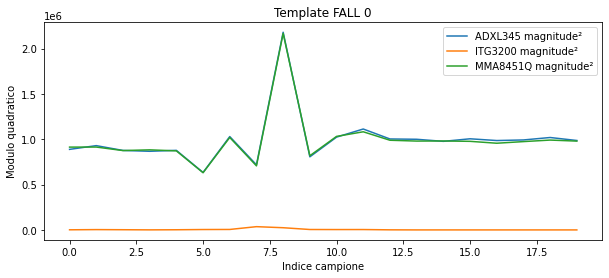

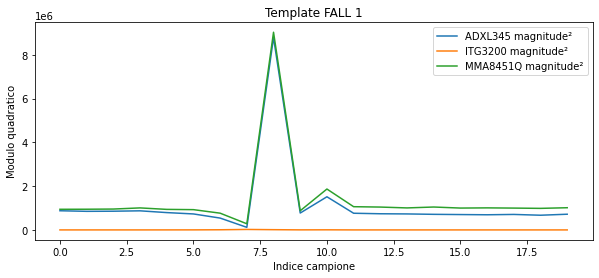

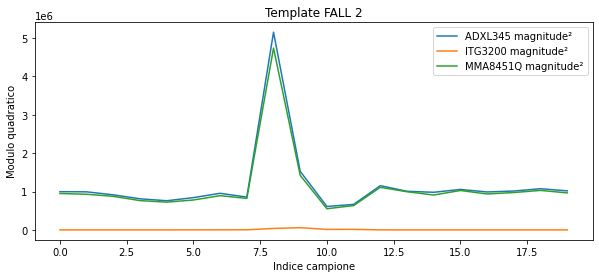

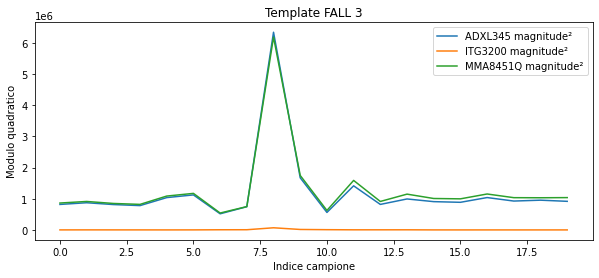

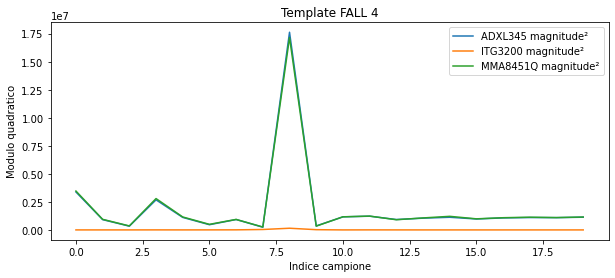

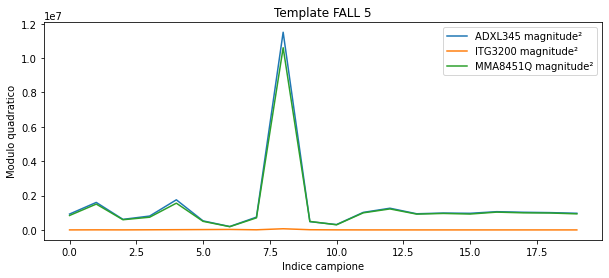

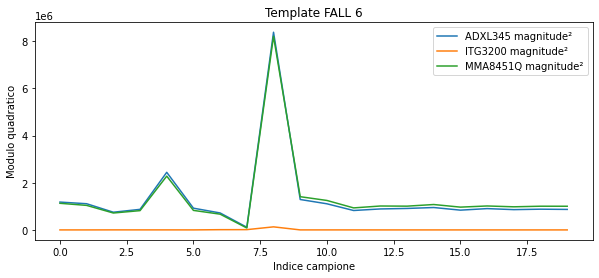

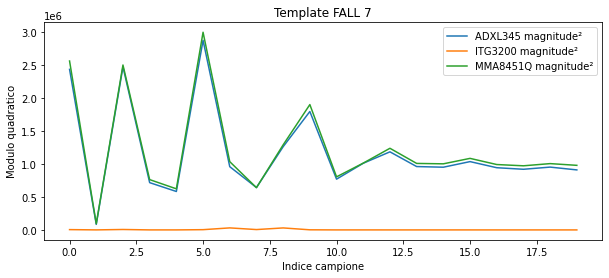

In [3]:
def squared_magnitudes(window: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    window = np.asarray(window, dtype=np.float64)
    adxl_mag2 = np.sum(window[:, 0:3] ** 2, axis=1)
    gyro_mag2 = np.sum(window[:, 3:6] ** 2, axis=1)
    mma_mag2 = np.sum(window[:, 6:9] ** 2, axis=1)
    return adxl_mag2, gyro_mag2, mma_mag2


for template_id, template in enumerate(FALL_TEMPLATES):
    adxl_mag2, gyro_mag2, mma_mag2 = squared_magnitudes(template)

    plt.figure(figsize=(10, 4))
    plt.plot(adxl_mag2, label="ADXL345 magnitude²")
    plt.plot(gyro_mag2, label="ITG3200 magnitude²")
    plt.plot(mma_mag2, label="MMA8451Q magnitude²")
    plt.title(f"Template FALL {template_id}")
    plt.xlabel("Indice campione")
    plt.ylabel("Modulo quadratico")
    plt.legend()
    plt.show()


## 3. Feature extraction

Per ciascun sensore vengono calcolate sette feature: media, varianza, minimo, massimo, range, media delle differenze assolute e massima differenza assoluta. Totale: 21 feature.

In [4]:
def signal_features(signal: np.ndarray) -> np.ndarray:
    signal = np.asarray(signal, dtype=np.float64)

    if signal.ndim != 1 or len(signal) != WINDOW_SIZE:
        raise ValueError(f"Expected a signal of length {WINDOW_SIZE}.")

    differences = np.abs(np.diff(signal))

    return np.array(
        [
            np.mean(signal),
            np.var(signal),
            np.min(signal),
            np.max(signal),
            np.max(signal) - np.min(signal),
            np.mean(differences) if differences.size else 0.0,
            np.max(differences) if differences.size else 0.0,
        ],
        dtype=np.float64,
    )


def extract_features(window: np.ndarray) -> np.ndarray:
    window = np.asarray(window, dtype=np.float64)

    if window.shape != (WINDOW_SIZE, NUM_CHANNELS):
        raise ValueError(
            f"Expected {(WINDOW_SIZE, NUM_CHANNELS)}, got {window.shape}."
        )

    adxl_mag2, gyro_mag2, mma_mag2 = squared_magnitudes(window)

    features = np.concatenate(
        [
            signal_features(adxl_mag2),
            signal_features(gyro_mag2),
            signal_features(mma_mag2),
        ]
    )

    if features.shape != (NUM_FEATURES,):
        raise RuntimeError(f"Unexpected feature shape: {features.shape}")

    return features


dict(zip(FEATURE_NAMES, extract_features(FALL_TEMPLATES[0])))


{'adxl_mean': 995851.8,
 'adxl_variance': 86285086315.85999,
 'adxl_min': 633731.0,
 'adxl_max': 2180814.0,
 'adxl_range': 1547083.0,
 'adxl_mean_abs_diff': 234718.15789473685,
 'adxl_max_abs_diff': 1462594.0,
 'gyro_mean': 4615.25,
 'gyro_variance': 78396588.6875,
 'gyro_min': 10.0,
 'gyro_max': 35909.0,
 'gyro_range': 35899.0,
 'gyro_mean_abs_diff': 4039.7368421052633,
 'gyro_max_abs_diff': 30843.0,
 'mma_mean': 987347.05,
 'mma_variance': 84480611370.0475,
 'mma_min': 631169.0,
 'mma_max': 2168283.0,
 'mma_range': 1537114.0,
 'mma_mean_abs_diff': 223732.84210526315,
 'mma_max_abs_diff': 1461497.0}

## 4. Generazione delle varianti FALL

Il rumore replica il generatore C:

- accelerometri: uniforme intero in `[-30, +30]` milli-g;
- giroscopio: uniforme intero in `[-5, +5]` deg/s.

In [5]:
def add_fall_noise(
    template: np.ndarray,
    rng: np.random.Generator,
) -> np.ndarray:
    noisy = np.asarray(template, dtype=np.int32).copy()

    noisy[:, 0:3] += rng.integers(
        -ACC_NOISE_MG,
        ACC_NOISE_MG + 1,
        size=(WINDOW_SIZE, 3),
    )

    noisy[:, 3:6] += rng.integers(
        -GYRO_NOISE_DPS,
        GYRO_NOISE_DPS + 1,
        size=(WINDOW_SIZE, 3),
    )

    noisy[:, 6:9] += rng.integers(
        -ACC_NOISE_MG,
        ACC_NOISE_MG + 1,
        size=(WINDOW_SIZE, 3),
    )

    return noisy.astype(np.float64)


def generate_fall_features(
    fall_templates: np.ndarray,
    variants_per_template: int,
    rng: np.random.Generator,
) -> Tuple[np.ndarray, np.ndarray]:
    feature_rows = []
    template_ids = []

    for template_id, template in enumerate(fall_templates):
        for _ in range(variants_per_template):
            noisy_window = add_fall_noise(template, rng)
            feature_rows.append(extract_features(noisy_window))
            template_ids.append(template_id)

    return (
        np.vstack(feature_rows),
        np.asarray(template_ids, dtype=np.int32),
    )


X_fall_train, fall_train_template_ids = generate_fall_features(
    FALL_TEMPLATES,
    TRAIN_VARIANTS_PER_TEMPLATE,
    np.random.default_rng(RANDOM_SEED),
)

X_fall_validation, fall_validation_template_ids = generate_fall_features(
    FALL_TEMPLATES,
    VALIDATION_VARIANTS_PER_TEMPLATE,
    np.random.default_rng(RANDOM_SEED + 1),
)

print("FALL train:", X_fall_train.shape)
print("FALL validation:", X_fall_validation.shape)


FALL train: (16000, 21)
FALL validation: (4000, 21)


## 5. Addestramento one-class multi-prototipo

Per ogni famiglia di caduta vengono appresi media e deviazione standard delle 21 feature. Il punteggio finale è la minima distanza standardizzata rispetto agli otto prototipi.

In [6]:
def train_prototypes(
    X: np.ndarray,
    template_ids: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray]:
    means = np.zeros((NUM_TEMPLATES, NUM_FEATURES), dtype=np.float64)
    scales = np.zeros_like(means)

    for template_id in range(NUM_TEMPLATES):
        rows = X[template_ids == template_id]
        if len(rows) == 0:
            raise ValueError(f"No rows for template {template_id}.")
        means[template_id] = np.mean(rows, axis=0)
        scales[template_id] = np.std(rows, axis=0)

    scales = np.maximum(scales, 1e-6)
    return means, scales


def distances_to_prototypes(
    X: np.ndarray,
    means: np.ndarray,
    scales: np.ndarray,
) -> np.ndarray:
    distances = []

    for template_id in range(NUM_TEMPLATES):
        standardized = (X - means[template_id]) / scales[template_id]
        distances.append(np.mean(standardized ** 2, axis=1))

    return np.column_stack(distances)


def fall_scores(
    X: np.ndarray,
    means: np.ndarray,
    scales: np.ndarray,
) -> np.ndarray:
    return np.min(distances_to_prototypes(X, means, scales), axis=1)


FALL_PROTOTYPE_MEAN, FALL_PROTOTYPE_SCALE = train_prototypes(
    X_fall_train,
    fall_train_template_ids,
)

fall_validation_scores = fall_scores(
    X_fall_validation,
    FALL_PROTOTYPE_MEAN,
    FALL_PROTOTYPE_SCALE,
)

print("Means:", FALL_PROTOTYPE_MEAN.shape)
print("Scales:", FALL_PROTOTYPE_SCALE.shape)
print("FALL score range:",
      float(np.min(fall_validation_scores)),
      float(np.max(fall_validation_scores)))


Means: (8, 21)
Scales: (8, 21)
FALL score range: 0.11925663117398261 3.7158839579645604


## 6. Generazione NORMAL per il test negativo

La generazione replica la regola dei quantili del nodo. I dati NORMAL non partecipano al training.

In [7]:
def sample_normal_feature(
    quantiles: np.ndarray,
    rng: np.random.Generator,
) -> int:
    probability = int(rng.integers(0, 100))

    if probability < 60:
        lower, upper = int(quantiles[2]), int(quantiles[4])
    elif probability < 85:
        lower, upper = int(quantiles[1]), int(quantiles[5])
    else:
        lower, upper = int(quantiles[0]), int(quantiles[6])

    return int(rng.integers(lower, upper + 1))


def generate_normal_window(rng: np.random.Generator) -> np.ndarray:
    window = np.zeros((WINDOW_SIZE, NUM_CHANNELS), dtype=np.float64)

    for sample_index in range(WINDOW_SIZE):
        for feature_index in range(NUM_CHANNELS):
            window[sample_index, feature_index] = sample_normal_feature(
                NORMAL_QUANTILES[feature_index],
                rng,
            )

    return window


def generate_normal_features(
    number_of_windows: int,
    rng: np.random.Generator,
) -> np.ndarray:
    return np.vstack(
        [
            extract_features(generate_normal_window(rng))
            for _ in range(number_of_windows)
        ]
    )


X_normal_test = generate_normal_features(
    NUM_NORMAL_TEST_WINDOWS,
    np.random.default_rng(RANDOM_SEED + 2),
)

normal_test_scores = fall_scores(
    X_normal_test,
    FALL_PROTOTYPE_MEAN,
    FALL_PROTOTYPE_SCALE,
)

print("NORMAL test:", X_normal_test.shape)
print("NORMAL score range:",
      float(np.min(normal_test_scores)),
      float(np.max(normal_test_scores)))


NORMAL test: (10000, 21)
NORMAL score range: 73.29100697657191 2051.9238726243193


## 7. Scelta della soglia

Una finestra è FALL quando `fall_score <= threshold`. La soglia deve garantire recall elevato e falsi positivi contenuti.

In [8]:
def evaluate_threshold(
    threshold: float,
    positive_scores: np.ndarray,
    negative_scores: np.ndarray,
) -> dict:
    recall = float(np.mean(positive_scores <= threshold))
    false_positive_rate = float(np.mean(negative_scores <= threshold))
    specificity = 1.0 - false_positive_rate

    return {
        "threshold": float(threshold),
        "fall_recall": recall,
        "fall_false_negative_rate": 1.0 - recall,
        "normal_false_positive_rate": false_positive_rate,
        "normal_specificity": specificity,
        "balanced_accuracy": 0.5 * (recall + specificity),
    }


for quantile in [0.95, 0.975, 0.99, 0.995, 0.999]:
    result = evaluate_threshold(
        np.quantile(fall_validation_scores, quantile),
        fall_validation_scores,
        normal_test_scores,
    )

    print(
        f"quantile={quantile:.3f} | "
        f"threshold={result['threshold']:.6f} | "
        f"recall={result['fall_recall']:.3%} | "
        f"FPR_NORMAL={result['normal_false_positive_rate']:.3%} | "
        f"balanced_acc={result['balanced_accuracy']:.3%}"
    )


quantile=0.950 | threshold=1.938289 | recall=95.000% | FPR_NORMAL=0.000% | balanced_acc=97.500%
quantile=0.975 | threshold=2.159247 | recall=97.500% | FPR_NORMAL=0.000% | balanced_acc=98.750%
quantile=0.990 | threshold=2.437411 | recall=99.000% | FPR_NORMAL=0.000% | balanced_acc=99.500%
quantile=0.995 | threshold=2.571071 | recall=99.500% | FPR_NORMAL=0.000% | balanced_acc=99.750%
quantile=0.999 | threshold=3.203851 | recall=99.900% | FPR_NORMAL=0.000% | balanced_acc=99.950%


In [9]:
TARGET_RECALL = 0.99

candidate_thresholds = np.unique(
    np.quantile(
        fall_validation_scores,
        np.linspace(TARGET_RECALL, 0.9999, 100),
    )
)

candidate_results = [
    evaluate_threshold(
        threshold,
        fall_validation_scores,
        normal_test_scores,
    )
    for threshold in candidate_thresholds
]

feasible_results = [
    result
    for result in candidate_results
    if result["fall_recall"] >= TARGET_RECALL
]

if not feasible_results:
    raise RuntimeError("No threshold reaches the requested recall.")

best_result = min(
    feasible_results,
    key=lambda result: (
        result["normal_false_positive_rate"],
        -result["fall_recall"],
        result["threshold"],
    ),
)

FALL_DISTANCE_THRESHOLD = best_result["threshold"]

print("Selected operating point")
for key, value in best_result.items():
    print(f"{key}: {value:.9g}" if key == "threshold" else f"{key}: {value:.4%}")


Selected operating point
threshold: 3.43402435
fall_recall: 99.9750%
fall_false_negative_rate: 0.0250%
normal_false_positive_rate: 0.0000%
normal_specificity: 100.0000%
balanced_accuracy: 99.9875%


## 8. Distribuzione dei punteggi

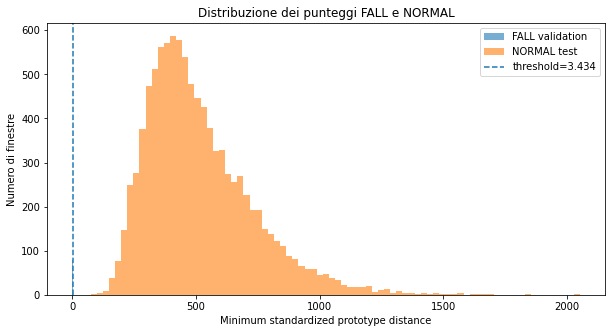

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(fall_validation_scores, bins=80, alpha=0.6, label="FALL validation")
plt.hist(normal_test_scores, bins=80, alpha=0.6, label="NORMAL test")
plt.axvline(
    FALL_DISTANCE_THRESHOLD,
    linestyle="--",
    label=f"threshold={FALL_DISTANCE_THRESHOLD:.4g}",
)
plt.xlabel("Minimum standardized prototype distance")
plt.ylabel("Numero di finestre")
plt.title("Distribuzione dei punteggi FALL e NORMAL")
plt.legend()
plt.show()


## 9. Matrice di confusione e metriche

In [11]:
fall_predictions = fall_validation_scores <= FALL_DISTANCE_THRESHOLD
normal_predictions = normal_test_scores <= FALL_DISTANCE_THRESHOLD

tp = int(np.sum(fall_predictions))
fn = int(np.sum(~fall_predictions))
fp = int(np.sum(normal_predictions))
tn = int(np.sum(~normal_predictions))

confusion_matrix = np.array([[tn, fp], [fn, tp]], dtype=np.int64)

print("Rows: true NORMAL, true FALL")
print("Columns: predicted NORMAL, predicted FALL")
print(confusion_matrix)

recall = tp / (tp + fn) if (tp + fn) else 0.0
precision = tp / (tp + fp) if (tp + fp) else 0.0
specificity = tn / (tn + fp) if (tn + fp) else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

print(f"FALL recall: {recall:.4%}")
print(f"FALL precision on synthetic mix: {precision:.4%}")
print(f"NORMAL specificity: {specificity:.4%}")
print(f"F1: {f1:.4%}")


Rows: true NORMAL, true FALL
Columns: predicted NORMAL, predicted FALL
[[10000     0]
 [    1  3999]]
FALL recall: 99.9750%
FALL precision on synthetic mix: 100.0000%
NORMAL specificity: 100.0000%
F1: 99.9875%


## 10. Analisi per template

In [12]:
validation_distances = distances_to_prototypes(
    X_fall_validation,
    FALL_PROTOTYPE_MEAN,
    FALL_PROTOTYPE_SCALE,
)

nearest_prototypes = np.argmin(validation_distances, axis=1)

for template_id in range(NUM_TEMPLATES):
    mask = fall_validation_template_ids == template_id
    scores = fall_validation_scores[mask]
    predictions = scores <= FALL_DISTANCE_THRESHOLD
    correct_nearest = nearest_prototypes[mask] == template_id

    print(
        f"Template {template_id}: "
        f"recall={np.mean(predictions):.3%}, "
        f"nearest-own-prototype={np.mean(correct_nearest):.3%}, "
        f"mean-score={np.mean(scores):.6f}"
    )


Template 0: recall=100.000%, nearest-own-prototype=100.000%, mean-score=0.989976
Template 1: recall=100.000%, nearest-own-prototype=100.000%, mean-score=0.973412
Template 2: recall=100.000%, nearest-own-prototype=100.000%, mean-score=1.014510
Template 3: recall=100.000%, nearest-own-prototype=100.000%, mean-score=0.996598
Template 4: recall=99.800%, nearest-own-prototype=100.000%, mean-score=0.999635
Template 5: recall=100.000%, nearest-own-prototype=100.000%, mean-score=1.038945
Template 6: recall=100.000%, nearest-own-prototype=100.000%, mean-score=1.010188
Template 7: recall=100.000%, nearest-own-prototype=100.000%, mean-score=1.011137


## 11. Sanity check equivalente al ciclo C

In [13]:
def c_style_fall_score(features: np.ndarray) -> float:
    best_distance = float("inf")

    for template_id in range(NUM_TEMPLATES):
        distance = 0.0

        for feature_id in range(NUM_FEATURES):
            z = (
                features[feature_id]
                - FALL_PROTOTYPE_MEAN[template_id, feature_id]
            ) / FALL_PROTOTYPE_SCALE[template_id, feature_id]

            distance += z * z

        distance /= NUM_FEATURES
        best_distance = min(best_distance, distance)

    return float(best_distance)


for index in [0, 1, len(X_fall_validation) - 1]:
    vectorized_score = fall_scores(
        X_fall_validation[index:index + 1],
        FALL_PROTOTYPE_MEAN,
        FALL_PROTOTYPE_SCALE,
    )[0]

    loop_score = c_style_fall_score(X_fall_validation[index])

    print(
        index,
        vectorized_score,
        loop_score,
        np.isclose(vectorized_score, loop_score, rtol=1e-12, atol=1e-12),
    )


0 1.3746237787300324 1.3746237787300324 True
1 2.3872199488670716 2.3872199488670724 True
3999 0.3250207580806567 0.3250207580806567 True


## 12. Esportazione del modello in C

Il modello viene esportato come 8×21 medie, 8×21 scale e una soglia. Non è necessaria emlearn per questo modello.

In [14]:
def format_c_float(value: float) -> str:
    if not np.isfinite(value):
        raise ValueError(f"Non-finite value: {value}")

    text = f"{float(value):.9g}"
    if "e" not in text.lower() and "." not in text:
        text += ".0"

    return text + "f"


def c_matrix(name: str, matrix: np.ndarray) -> str:
    rows, columns = matrix.shape
    lines = [f"static const float {name}[{rows}][{columns}] = {{"]

    for row in matrix:
        values = ", ".join(format_c_float(value) for value in row)
        lines.append(f"  {{ {values} }},")

    lines.append("};")
    return "\n".join(lines)


def build_c_header() -> str:
    return f'''#ifndef FALL_PROTOTYPE_MODEL_H_
#define FALL_PROTOTYPE_MODEL_H_

#define FALL_MODEL_NUM_PROTOTYPES {NUM_TEMPLATES}
#define FALL_MODEL_NUM_FEATURES {NUM_FEATURES}

{c_matrix("FALL_PROTOTYPE_MEAN", FALL_PROTOTYPE_MEAN)}

{c_matrix("FALL_PROTOTYPE_SCALE", FALL_PROTOTYPE_SCALE)}

static const float FALL_DISTANCE_THRESHOLD =
  {format_c_float(FALL_DISTANCE_THRESHOLD)};

#endif /* FALL_PROTOTYPE_MODEL_H_ */
'''


header_text = build_c_header()
output_header = Path("fall_prototype_model.h")
output_header.write_text(header_text, encoding="utf-8")

print(f"Written: {output_header.resolve()}")
print(f"Header size: {output_header.stat().st_size} bytes")
print("\n".join(header_text.splitlines()[:12]))


Written: /Users/susannabaldo/Desktop/IoT/IoT Project/fall_prototype_model.h
Header size: 4868 bytes
#ifndef FALL_PROTOTYPE_MODEL_H_
#define FALL_PROTOTYPE_MODEL_H_

#define FALL_MODEL_NUM_PROTOTYPES 8
#define FALL_MODEL_NUM_FEATURES 21

static const float FALL_PROTOTYPE_MEAN[8][21] = {
  { 996719.923f, 8.76180628e+10f, 634423.992f, 2183214.25f, 1548790.26f, 247683.788f, 1464330.97f, 4646.20028f, 78529651.8f, 13.6085f, 35920.257f, 35906.6485f, 4066.1855f, 30807.26f, 988034.984f, 8.5613234e+10f, 632096.292f, 2168550.45f, 1536454.16f, 240927.926f, 1462662.48f },
  { 1158305.59f, 3.12403756e+12f, 118668.279f, 8792862.14f, 8674193.86f, 1020149.56f, 8674193.86f, 2536.65918f, 26927690.4f, 11.639f, 21605.237f, 21593.598f, 2540.79221f, 14716.0825f, 1385887.31f, 3.14800623e+12f, 281192.78f, 9033547.25f, 8752354.47f, 1051621.1f, 8752354.47f },
  { 1169559.21f, 8.70719733e+11f, 609737.74f, 5152164.53f, 4542426.79f, 551219.02f, 4294943.85f, 6750.44102f, 216692248.0f, 15.045f, 57878.9945f, 57863.949

## 13. Salvataggio degli artefatti

In [15]:
OUTPUT_DIR = Path("fall_model_artifacts")
OUTPUT_DIR.mkdir(exist_ok=True)

np.save(OUTPUT_DIR / "fall_prototype_mean.npy", FALL_PROTOTYPE_MEAN)
np.save(OUTPUT_DIR / "fall_prototype_scale.npy", FALL_PROTOTYPE_SCALE)
np.save(OUTPUT_DIR / "fall_validation_scores.npy", fall_validation_scores)
np.save(OUTPUT_DIR / "normal_test_scores.npy", normal_test_scores)

metrics = {
    "threshold": float(FALL_DISTANCE_THRESHOLD),
    "target_recall": float(TARGET_RECALL),
    "fall_recall": float(recall),
    "fall_precision_on_synthetic_mix": float(precision),
    "normal_specificity": float(specificity),
    "normal_false_positive_rate": float(1.0 - specificity),
    "f1_on_synthetic_mix": float(f1),
    "true_positive": tp,
    "false_negative": fn,
    "false_positive": fp,
    "true_negative": tn,
    "train_variants_per_template": TRAIN_VARIANTS_PER_TEMPLATE,
    "validation_variants_per_template": VALIDATION_VARIANTS_PER_TEMPLATE,
    "normal_test_windows": NUM_NORMAL_TEST_WINDOWS,
    "random_seed": RANDOM_SEED,
}

(OUTPUT_DIR / "metrics.json").write_text(
    json.dumps(metrics, indent=2),
    encoding="utf-8",
)

(OUTPUT_DIR / "fall_prototype_model.h").write_text(
    header_text,
    encoding="utf-8",
)

print(json.dumps(metrics, indent=2))
print(f"Artifacts saved in: {OUTPUT_DIR.resolve()}")


{
  "threshold": 3.434024347660408,
  "target_recall": 0.99,
  "fall_recall": 0.99975,
  "fall_precision_on_synthetic_mix": 1.0,
  "normal_specificity": 1.0,
  "normal_false_positive_rate": 0.0,
  "f1_on_synthetic_mix": 0.9998749843730466,
  "true_positive": 3999,
  "false_negative": 1,
  "false_positive": 0,
  "true_negative": 10000,
  "train_variants_per_template": 2000,
  "validation_variants_per_template": 500,
  "normal_test_windows": 10000,
  "random_seed": 42
}
Artifacts saved in: /Users/susannabaldo/Desktop/IoT/IoT Project/fall_model_artifacts


## 14. Funzione finale di inferenza

In [16]:
def predict_window(window: np.ndarray) -> dict:
    features = extract_features(window)

    distances = []
    for template_id in range(NUM_TEMPLATES):
        z = (
            features - FALL_PROTOTYPE_MEAN[template_id]
        ) / FALL_PROTOTYPE_SCALE[template_id]

        distances.append(float(np.mean(z ** 2)))

    nearest_template = int(np.argmin(distances))
    score = float(distances[nearest_template])
    is_fall = score <= FALL_DISTANCE_THRESHOLD

    return {
        "state": "FALL" if is_fall else "NORMAL",
        "score": score,
        "threshold": float(FALL_DISTANCE_THRESHOLD),
        "nearest_template": nearest_template,
        "all_distances": distances,
    }


test_fall = add_fall_noise(
    FALL_TEMPLATES[0],
    np.random.default_rng(999),
)

test_normal = generate_normal_window(
    np.random.default_rng(1000),
)

print("Example FALL:", predict_window(test_fall))
print("Example NORMAL:", predict_window(test_normal))


Example FALL: {'state': 'FALL', 'score': 0.5572434042498671, 'threshold': 3.434024347660408, 'nearest_template': 0, 'all_distances': [0.5572434042498671, 2034.047558204837, 522.7870367455358, 954.7309302686806, 5816.339153614833, 2814.728122777238, 2400.7425062280727, 604.7728286504881]}
Example NORMAL: {'state': 'NORMAL', 'score': 328.67681230437745, 'threshold': 3.434024347660408, 'nearest_template': 0, 'all_distances': [328.67681230437745, 2004.4700319643005, 930.2426483337348, 1386.0626986754578, 6298.2484586187265, 3139.5694338205317, 2635.8133317923284, 688.042755274484]}


## Note metodologiche

1. Il modello è specializzato sulle otto famiglie di caduta incorporate nel simulatore.
2. La validazione con nuovo rumore misura robustezza alle perturbazioni, non generalizzazione a ogni possibile caduta reale.
3. I dati NORMAL sintetici preservano le distribuzioni marginali dei singoli assi, ma non tutta la struttura temporale delle attività quotidiane.
4. Per una valutazione più realistica si dovrebbero aggiungere finestre temporali NORMAL e cadute non usate nella selezione dei template.
5. Nel nodo, `force_fall_sequence` deve controllare solo la generazione; la decisione deve provenire esclusivamente dal modello.